<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/Dropouts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

n_samples = 300

study_hours = np.random.uniform(0, 10, n_samples)
sleep_hours = np.random.uniform(4, 9, n_samples)
attendance = np.random.uniform(40, 100, n_samples)

X = np.column_stack([
    study_hours,
    sleep_hours,
    attendance
])

# Formula to decide pass/fail
score = (
    0.5 * study_hours
    + 0.2 * sleep_hours
    + 0.05 * attendance
)

y = (score > 7).astype(float)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (300, 3)
Output shape: (300,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, 0] /= 10
X_train_scaled[:, 1] /= 10
X_train_scaled[:, 2] /= 100

X_test_scaled[:, 0] /= 10
X_test_scaled[:, 1] /= 10
X_test_scaled[:, 2] /= 100

#Model Without Dropout


In [5]:
model_without_dropout = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_without_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_without_dropout = model_without_dropout.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4667 - loss: 0.6908 - val_accuracy: 0.5222 - val_loss: 0.6730
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5810 - loss: 0.6537 - val_accuracy: 0.5222 - val_loss: 0.6504
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5810 - loss: 0.6264 - val_accuracy: 0.5333 - val_loss: 0.6253
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6048 - loss: 0.5975 - val_accuracy: 0.6444 - val_loss: 0.5952
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7286 - loss: 0.5651 - val_accuracy: 0.7444 - val_loss: 0.5560
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7714 - loss: 0.5285 - val_accuracy: 0.7889 - val_loss: 0.5136
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7762 - loss: 0.4931 - val_accuracy: 0.8333 - val_loss: 0.4748
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7762 - loss: 0.4632 - val_accuracy: 0.8333 - val_loss: 0.4412
Epoc

#Model With Dropout

In [6]:
model_with_dropout = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_with_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_with_dropout = model_with_dropout.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5762 - loss: 0.6714 - val_accuracy: 0.5222 - val_loss: 0.6670
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5762 - loss: 0.6513 - val_accuracy: 0.5222 - val_loss: 0.6543
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6000 - loss: 0.6313 - val_accuracy: 0.5222 - val_loss: 0.6386
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5905 - loss: 0.6137 - val_accuracy: 0.5222 - val_loss: 0.6162
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6190 - loss: 0.6008 - val_accuracy: 0.6111 - val_loss: 0.5874
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6476 - loss: 0.5875 - val_accuracy: 0.7444 - val_loss: 0.5574
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7286 - loss: 0.5442 - val_accuracy: 0.7778 - val_loss: 0.5263
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7286 - loss: 0.5365 - val_accuracy: 0.8222 - val_loss:

In [7]:
without_loss, without_acc = model_without_dropout.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

with_loss, with_acc = model_with_dropout.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Without Dropout Test Accuracy:", without_acc)
print("With Dropout Test Accuracy:", with_acc)

print("Without Dropout Test Loss:", without_loss)
print("With Dropout Test Loss:", with_loss)

Without Dropout Test Accuracy: 0.9888888597488403
With Dropout Test Accuracy: 1.0
Without Dropout Test Loss: 0.02624422125518322
With Dropout Test Loss: 0.035156503319740295


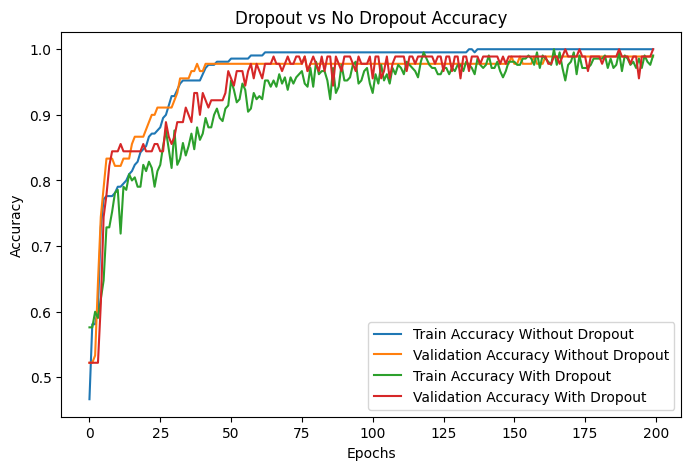

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_without_dropout.history['accuracy'],
    label='Train Accuracy Without Dropout'
)

plt.plot(
    history_without_dropout.history['val_accuracy'],
    label='Validation Accuracy Without Dropout'
)

plt.plot(
    history_with_dropout.history['accuracy'],
    label='Train Accuracy With Dropout'
)

plt.plot(
    history_with_dropout.history['val_accuracy'],
    label='Validation Accuracy With Dropout'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Dropout vs No Dropout Accuracy")

plt.legend()
plt.show()

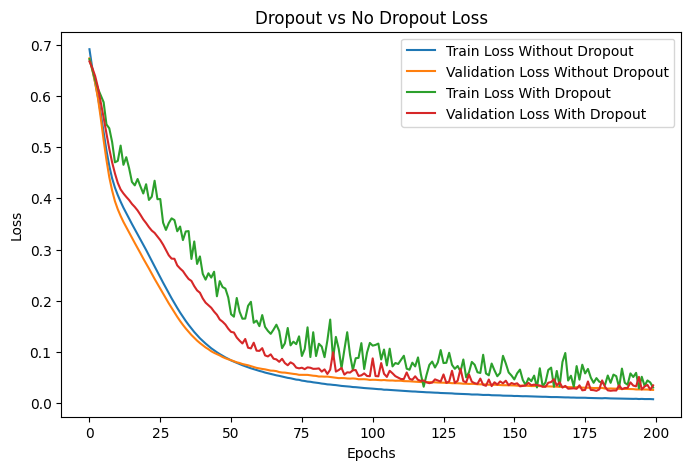

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_without_dropout.history['loss'],
    label='Train Loss Without Dropout'
)

plt.plot(
    history_without_dropout.history['val_loss'],
    label='Validation Loss Without Dropout'
)

plt.plot(
    history_with_dropout.history['loss'],
    label='Train Loss With Dropout'
)

plt.plot(
    history_with_dropout.history['val_loss'],
    label='Validation Loss With Dropout'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Dropout vs No Dropout Loss")

plt.legend()
plt.show()